In [1]:
import os
import time
import warnings
from datetime import datetime
from collections import OrderedDict
import numpy as np
import scipy
import sksparse.cholmod
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from utils_2_subdomains import construct_oras, Exp, set_seed
from utils_N_subdomains import decompose_domain, get_subdomains_endpoints

In [2]:
set_seed(42)
device = "cpu"
NUM_SUBDOMAINS = 10
ETA = 1
TOL = 1e-6
print(f"{NUM_SUBDOMAINS} subdomains")
method = 'mlp'
data = np.load("data_N_subdomains/data_mesh_squares_20-1000.npy", allow_pickle=True).item()
NUM_SAMPLES = 3
if method == 'mlp':
    NUM_TRAIN_SUBDOMAINS = 10
    mlp_pars = OrderedDict(
        [
        ("fc1", torch.nn.Linear(3, 64, dtype=torch.float64)),
        ("nl1", torch.nn.Sigmoid()),
        ("fc2", torch.nn.Linear(64, 32, dtype=torch.float64)),
        ("nl2", torch.nn.Sigmoid()),
        ("fc3", torch.nn.Linear(32, 2, dtype=torch.float64)),
        ("nl3", Exp())
        ]
    )
    mlp = torch.nn.Sequential(mlp_pars)
    # paramfile = f"results/train_meshrange_{NUM_TRAIN_SUBDOMAINS}_subdomains_lr0.005_20260401_133017/epoch_100"
    # paramfile = f"results/train_meshrange-tolvalid20_10_subdomains_lr0.005_20260402_203622/epoch_40"
    # paramfile = f"results/train_meshrange-tolvalid20-exp_10_subdomains_lr5e-05_20260404_183158/epoch_1010"
    paramfile = f"results/train_meshrange-tolvalid20-exp_{NUM_TRAIN_SUBDOMAINS}_subdomains_lr0.001_20260405_222100/epoch_610"
    pars = torch.load(paramfile, weights_only=False)
    mlp.load_state_dict(pars['mlp'])
    mlp.to(device)
    expname = paramfile.split('_')[1]
    method = method + str(NUM_TRAIN_SUBDOMAINS) + expname
    print(mlp)

10 subdomains
Sequential(
  (fc1): Linear(in_features=3, out_features=64, bias=True)
  (nl1): Sigmoid()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (nl2): Sigmoid()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (nl3): Exp()
)


In [3]:
pvals, qvals = [], []
pvals_mlp_last, qvals_mlp_last = [], []
for met in ['oo2', 'mlp', 'last']:  # 'mlp' should always be before 'last'
    print(met)
    for s in range(30, 31):
        amat_csr = data['amatcsr_list'][s]
        hvalx, hvaly = data['hvalx_list'][s], data['hvaly_list'][s]
        etaval = data['etaval_list'][s]
        evecs = data['evecs_list'][s]
        num_dofs = amat_csr.shape[0]
        num_x, num_y = num_dofs**(1/2), num_dofs**(1/2)
        overlap_pairs = decompose_domain(num_dofs, num_y, NUM_SUBDOMAINS)
        endpoints = get_subdomains_endpoints(overlap_pairs, num_dofs)
        i1, i2 = overlap_pairs[0]
        size = (i2-i1)//2
        overlaps = [idx for pair in overlap_pairs for idx in pair]
        overlaps = [0] + overlaps + [num_dofs]

        amatcsr_list = []
        # Decompose system matrix
        for i in range(NUM_SUBDOMAINS):
            idx_start, idx_end = endpoints[i]            
            amat_csr_i = amat_csr[idx_start:idx_end, idx_start:idx_end]
            amatcsr_list.append(amat_csr_i)
        assert hvalx == hvaly
        errors, runtimes, num_iters_tol = [], [], []
        for b, evec in enumerate(evecs.T):
            evec_t = evec.copy()
            n_test = 0
            time_start = time.time()
            while np.linalg.norm(evec_t) > TOL:
                rvec = amat_csr @ evec_t
                # Predict or compute p and q
                if met == 't2':
                    pval = np.sqrt(etaval)
                    qval = 1/(2*np.sqrt(etaval))
                elif met == 't2b':
                    interior_size = 1/NUM_SUBDOMAINS-hvalx
                    pval = np.sqrt(etaval)*1/np.tanh(np.sqrt(etaval)*interior_size)
                    qval = 1/np.tanh(interior_size*np.sqrt(etaval))/np.sqrt(etaval) - interior_size/np.sinh(interior_size*np.sqrt(etaval))**2
                    qval = qval/2
                elif met == 'last':
                    pval = pvals_mlp_last[b]
                    qval = qvals_mlp_last[b]
                else:
                    pval = 2**(-3/5) * (np.pi**2 + etaval)**(2/5) * hvalx**(-1/5)
                    qval = 2**(-1/5) * (np.pi**2 + etaval)**(-1/5) * hvalx**(3/5)
                if 'mlp' in met:
                    rvct = torch.tensor(rvec)
                    etavct = torch.tensor(etaval, device=device).unsqueeze(0)
                    hvctx = torch.tensor(hvalx, device=device).unsqueeze(0)
                    rnorm_logratio_tr = torch.log(rvct.norm()).unsqueeze(0)
                    featvct_tr = torch.cat([rnorm_logratio_tr, etavct, hvctx], dim=0).to(device)
                    with torch.no_grad():
                        pscl_corr, qscl_corr = mlp(featvct_tr)
                    pval, qval =  pval*pscl_corr.numpy().item(), qval*qscl_corr.numpy().item()
                pvals.append({'Method': met, 'batch_idx': b, 'iteration': n_test, 'val': pval})
                qvals.append({'Method': met, 'batch_idx': b, 'iteration': n_test, 'val': qval})
                # Modify subdomain matrices
                amatcsr_tilde_list = []
                amatcsr_i = amatcsr_list[0]
                for j in range(1, NUM_SUBDOMAINS):
                    amatcsr_j = amatcsr_list[j]
                    amatcsr_tilde_i, amatcsr_tilde_j = construct_oras(amatcsr_i, amatcsr_j, etaval, hvalx, size, pval, qval)
                    amatcsr_tilde_list.append(amatcsr_tilde_i)
                    amatcsr_i = amatcsr_tilde_j
                amatcsr_tilde_list.append(amatcsr_tilde_j)

                amatcsc_tilde_block = scipy.sparse.block_diag(amatcsr_tilde_list, format='csc')
                rvec_ext = np.concatenate([rvec[s:e] for s, e in endpoints])

                try:
                    factor = sksparse.cholmod.cholesky(amatcsc_tilde_block)
                    evec_ext = factor(rvec_ext)
                except sksparse.cholmod.CholmodNotPositiveDefiniteError:
                    warnings.warn(
                        f"Matrix with {amat_csr} DoFs is not SPD. Skipping Cholesky decomposition.",
                        RuntimeWarning
                    )
                    evec_ext = scipy.sparse.spsolve(amatcsc_tilde_block, rvec_ext)
                # Compute correction vector
                corrvec = np.zeros_like(evec)
                offset = 0
                for i, (idx_start, idx_end) in enumerate(endpoints):
                    block_size = idx_end - idx_start
                    evec_i = evec_ext[offset:offset + block_size]
                    offset += block_size
                    if i == 0:
                        corrvec[idx_start:idx_end-size] = evec_i[:-size]
                    elif i == NUM_SUBDOMAINS-1:
                        corrvec[idx_start+size:idx_end] = evec_i[size:]
                    else:
                        corrvec[idx_start+size:idx_end-size] = evec_i[size:-size]
                evec_t = evec_t - corrvec
                # print(n_test, np.linalg.norm(evec_t))
                n_test += 1
            runtime = time.time() - time_start
            error = np.linalg.norm(evec_t)
            errors.append(error)
            runtimes.append(runtime)
            num_iters_tol.append(n_test)
            if 'mlp' in met:
                pvals_mlp_last.append(pval)
                qvals_mlp_last.append(qval)
        errors_mean, runtimes_mean, num_iters_tol_mean = np.mean(errors), np.mean(runtimes), np.mean(num_iters_tol)
        errors_sd, runtimes_sd, num_iters_tol_sd = np.std(errors), np.std(runtimes), np.std(num_iters_tol)
        print(f'{num_dofs}, {errors_mean}, {num_iters_tol_mean}, {runtimes_mean}')

oo2
102400, 8.593502538654498e-07, 33.8, 4.36409912109375
mlp
102400, 6.547833028677616e-07, 25.8, 3.8219801902771
last
102400, 8.09783608279539e-07, 31.2, 4.0119300365448


In [14]:
p_df = pd.DataFrame(pvals)
q_df = pd.DataFrame(qvals)
p_df['Coefficient'], q_df['Coefficient'] = 'p', 'q'
values = pd.concat([p_df, q_df], axis=0)

In [15]:
values_copy = values.copy()

In [16]:
values_copy['Method'] = values_copy['Method'].replace({'mlp': r'UORAS(10)(k)', 
                                                       'oo2': 'OO2', 
                                                       'last': r'UORAS(10)(K)'})

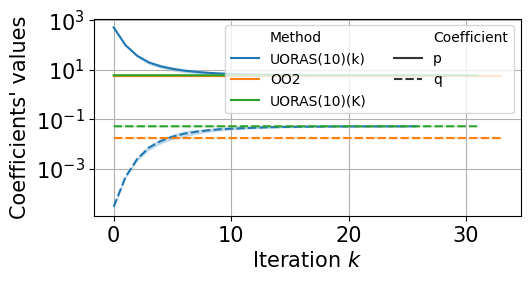

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(5.5, 3.4))
sns.lineplot(values_copy, x='iteration', y="val", hue="Method", style="Coefficient", 
             hue_order=[r'UORAS(10)(k)', 'OO2', r'UORAS(10)(K)'], errorbar='sd')
plt.yscale('log')
plt.grid()
plt.legend(ncol=2, fontsize=10)
plt.xlabel("Iteration $k$", fontsize=15)
plt.ylabel("Coefficients' values", fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.savefig('results_fig/coefficients.pdf', bbox_inches='tight', pad_inches=0.02)